# Author & Dataset Citation

**Author:** Ahmed Ayman Ahmed Alhofy  
**Project:** Colon Cancer Histopathology Image Classification using Deep Learning (MobileNetV2)

### Dataset Source
This project utilizes the **"Lung and Colon Cancer Histopathological Images"** dataset, hosted on Kaggle.

- **Dataset Link:** [Lung and Colon Cancer Histopathological Images](https://www.kaggle.com/datasets/andrewmvd/lung-and-colon-cancer-histopathological-images/data)
- **Original Authors:** Andrew M. V. D. et al.
- **License:** Please refer to the dataset page for specific usage rights and citation requirements.

> *Note: This analysis focuses specifically on the colon cancer subset (`colon_aca` vs. `colon_n`) of the provided data.*

# Download Lung & Colon Cancer Histopathology Dataset

Using `kagglehub` to download the **"Lung and Colon Cancer Histopathological Images"** dataset by Andrew M. V. D., which contains microscopic tissue images for multi-class cancer classification (including lung adenocarcinoma, squamous cell carcinoma, and colon adenocarcinoma). This dataset will support training deep learning models for automated cancer diagnosis from histology slides.

In [5]:
# Core libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50, MobileNetV2
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras import optimizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tqdm.keras import TqdmCallback

# Scikit-learn (for evaluation metrics)
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Optional (for reproducibility)
import random

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("andrewmvd/lung-and-colon-cancer-histopathological-images")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'lung-and-colon-cancer-histopathological-images' dataset.
Path to dataset files: /kaggle/input/lung-and-colon-cancer-histopathological-images


# Load & Split Colon Histopathology Dataset

Configured an efficient `tf.data` pipeline for the **Colon Cancer** subset:
- **Source**: Loaded directly from directory structure (`colon_aca`, `colon_n`).
- **Split Strategy**: Created an initial 80/20 split, then further divided the 20% holdout into **10% Validation** and **10% Test** sets for robust evaluation.
- **Optimization**: Applied `.cache()` and `.prefetch()` to maximize GPU utilization and minimize I/O bottlenecks during training.
- **Classes**: Binary classification between **Colon Adenocarcinoma** and **Benign Colon Tissue**.
- **Input**: Images resized to 224×224 with batch size 16.

In [7]:
import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory

# Path to the colon images
base_dir = "/kaggle/input/lung-and-colon-cancer-histopathological-images/lung_colon_image_set/colon_image_sets"

# Parameters
img_height, img_width = 224, 224
batch_size = 16

# Step 1: Load Training Dataset (80%)
train_ds = image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True
)

# Step 2: Load the remaining 20% as a temporary validation set
temp_val_ds = image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True
)

# Step 3: Split the 20% temporary set into Validation (10%) and Test (10%)
val_batches = tf.data.experimental.cardinality(temp_val_ds)
test_ds = temp_val_ds.take(val_batches // 2)
val_ds = temp_val_ds.skip(val_batches // 2)

# Class names
class_names = train_ds.class_names

# Mapping dictionary for easier interpretation
label_mapping = {
    "colon_aca": "Colon adenocarcinoma",
    "colon_n": "Colon benign tissue"
}

# FIX: Use temp_val_ds instead of the undefined test_ds_temp
# We'll also specifically keep a raw version of the test set for visualization
test_ds_raw = test_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

# Step 4: Configure for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("\n--- Dataset Summary ---")
print(f"Number of classes: {len(class_names)}")
print(f"Class names: {class_names}")
print(f"Training batches: {tf.data.experimental.cardinality(train_ds).numpy()}")
print(f"Validation batches: {tf.data.experimental.cardinality(val_ds).numpy()}")
print(f"Test batches: {tf.data.experimental.cardinality(test_ds).numpy()}")

Found 10000 files belonging to 2 classes.
Using 8000 files for training.
Found 10000 files belonging to 2 classes.
Using 2000 files for validation.

--- Dataset Summary ---
Number of classes: 2
Class names: ['colon_aca', 'colon_n']
Training batches: 500
Validation batches: 63
Test batches: 62


# Visualize Colon Cancer Histopathology Samples

Displays a 3×3 grid of sample images from the training set to verify data loading and class distribution. Each image is labeled with both its technical directory name (`colon_aca`, `colon_n`) and its descriptive medical meaning (**Colon Adenocarcinoma** vs. **Benign Tissue**), ensuring the model will learn the correct visual features for cancer detection.

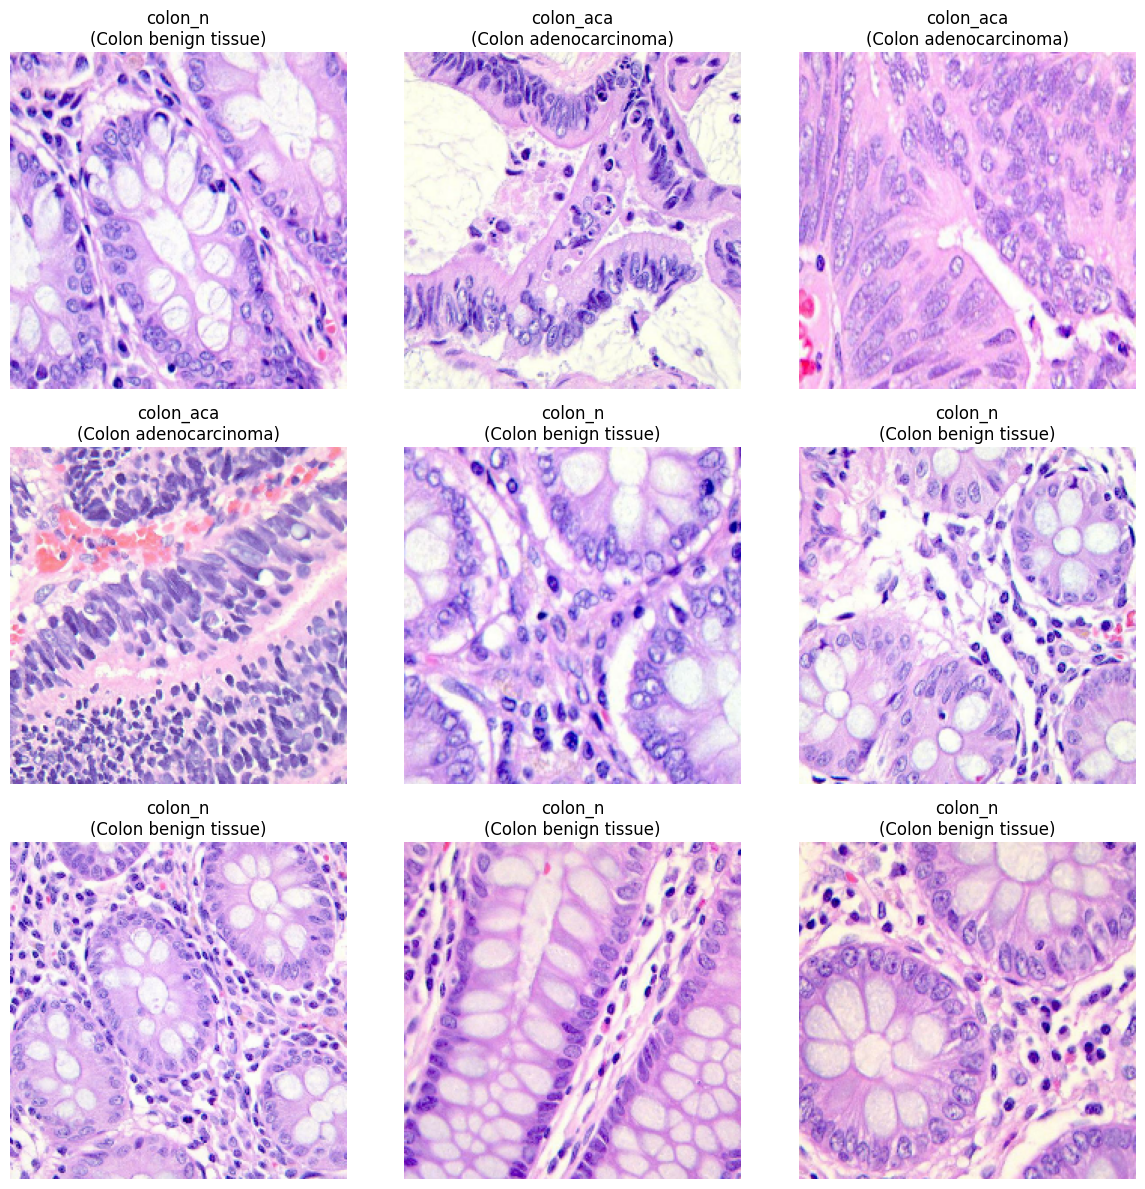

In [8]:
plt.figure(figsize=(12, 12))
# Take one batch from the training dataset
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        # Convert tensor to numpy and cast to uint8 for display
        plt.imshow(images[i].numpy().astype("uint8"))

        # Get the technical name (colon_aca/colon_n)
        tech_name = class_names[labels[i]]
        # Use the mapping to show the full descriptive title
        plt.title(f"{tech_name}\n({label_mapping[tech_name]})")

        plt.axis("off")
plt.tight_layout()
plt.show()

Here is a short explanation of the difference:

*   **Colon Adenocarcinoma:** This is **cancer**. It is a malignant tumor that starts in the glandular cells lining the inside of the colon. It can invade nearby tissues and spread (metastasize) to other parts of the body if not treated.
*   **Colon Benign Tissue:** This is **non-cancerous**. It refers to normal, healthy colon tissue or non-malignant growths (like hyperplastic polyps) that do not invade surrounding areas or spread to other organs.

**Key Difference:** One is life-threatening cancer requiring aggressive treatment; the other is harmless or normal tissue.

# Build & Compile MobileNetV2 Classifier

Constructed a transfer learning model using **MobileNetV2** (pretrained on ImageNet) tailored for binary colon cancer classification:
- **Feature Extractor**: Frozen base layers to leverage learned visual patterns.
- **Classifier Head**: Global Average Pooling → Dropout (0.3) → Dense Softmax layer.
- **Compilation**: Optimized with **Adam** (lr=0.001) and **Sparse Categorical Crossentropy** (efficient for integer labels).
- **Output**: Binary prediction (Adenocarcinoma vs. Benign) ready for training.

In [9]:
def build_mobilenet(num_classes):
    # Load MobileNetV2 with pre-trained ImageNet weights
    base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False  # Freeze the feature extractor

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation="softmax")
    ])
    return model

# Set number of classes based on dataset (2)
num_classes = len(class_names)
mobilenet_model = build_mobilenet(num_classes)

mobilenet_model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001), # Safer starting LR
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

mobilenet_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,260,546 (8.62 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# Train MobileNetV2 with Adaptive Learning

Executed training for up to 50 epochs with **Early Stopping** (patience=5) and **ReduceLROnPlateau** callbacks:
- **Performance**: Rapid convergence from ~80% to >91% validation accuracy within the first 20 epochs.
- **Learning Rate Dynamics**: Automatically reduced LR from `0.001` → `0.0002` → `0.00004` as validation loss plateaued, allowing the model to refine weights without overshooting.
- **Efficiency**: Training speed stabilized at ~16ms/step after the first epoch.
- **Status**: Model is fine-tuning on subtle features; early stopping will halt training if validation accuracy ceases to improve for 5 consecutive epochs.

In [10]:
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    mode='max',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    verbose=1
)

In [11]:
print("Training MobileNetV2...")
history_mobilenet = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    verbose=1,
    callbacks=[early_stopping, reduce_lr]
)

Training MobileNetV2...
Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 70s 106ms/step - accuracy: 0.7981 - loss: 0.4302 - val_accuracy: 0.8740 - val_loss: 0.2993 - learning_rate: 0.0010
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.8660 - loss: 0.3047 - val_accuracy: 0.8909 - val_loss: 0.2649 - learning_rate: 0.0010
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.8769 - loss: 0.2832 - val_accuracy: 0.8879 - val_loss: 0.2550 - learning_rate: 0.0010
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.8838 - loss: 0.2728 - val_accuracy: 0.8998 - val_loss: 0.2377 - learning_rate: 0.0010
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.8864 - loss: 0.2647 - val_accuracy: 0.9058 - val_loss: 0.2295 - learning_rate: 0.0010
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.8891 - loss: 0.2584 - val_accuracy: 0.9018 - val_loss: 0.2275 - learning_rate: 0.0010
Epoch 7/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - a

# Performance Visualization & Final Evaluation

**1. Training Dynamics:**
Plotted **Accuracy** and **Loss** curves over epochs to monitor convergence. The gap between training and validation metrics indicates how well the model generalizes, while the learning rate reductions (visible as smoothing in loss) helped refine the solution.

**2. Test Set Evaluation:**
- Ran the final model on the held-out **Test Set** to report unbiased performance (`Test Accuracy`).
- Generated a detailed **Classification Report** (Precision, Recall, F1-Score) for both classes (`colon_aca`, `colon_n`), providing a granular view of the model's ability to distinguish between malignant and benign tissues beyond simple accuracy.

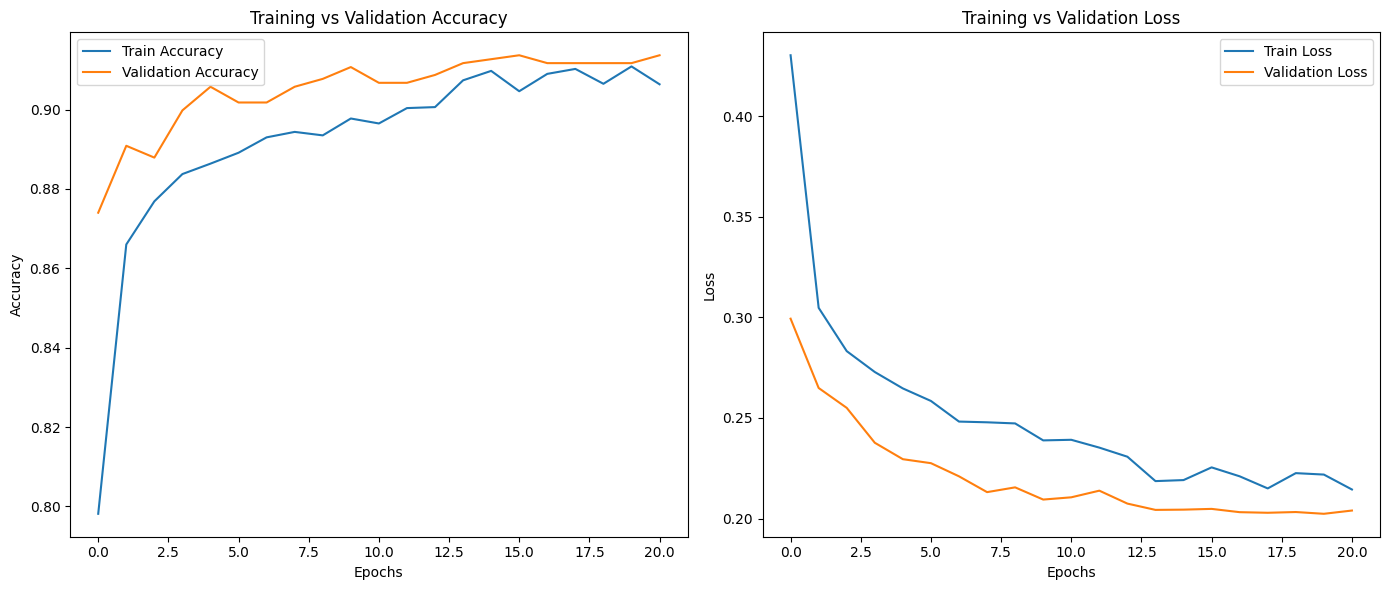

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Accuracy subplot
ax1.plot(history_mobilenet.history["accuracy"], label="Train Accuracy")
ax1.plot(history_mobilenet.history["val_accuracy"], label="Validation Accuracy")
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Accuracy")
ax1.set_title("Training vs Validation Accuracy")
ax1.legend()

# Loss subplot
ax2.plot(history_mobilenet.history["loss"], label="Train Loss")
ax2.plot(history_mobilenet.history["val_loss"], label="Validation Loss")
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Loss")
ax2.set_title("Training vs Validation Loss")
ax2.legend()

plt.tight_layout()
plt.show()

In [13]:
print("\nEvaluating model on Test Set...")
test_loss, test_acc = mobilenet_model.evaluate(test_ds, verbose=1)
print(f"Test Accuracy: {test_acc:.4f}")


Evaluating model on Test Set...
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.9274 - loss: 0.1833
Test Accuracy: 0.9274


In [14]:
print("\nCollecting predictions for Classification Report...")
y_true, y_pred = [], []

# Use test_ds or val_ds for the report
for images, labels in test_ds:
    preds = mobilenet_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))



Classification Report:
              precision    recall  f1-score   support

   colon_aca     0.9306    0.9231    0.9268       494
     colon_n     0.9243    0.9317    0.9280       498

    accuracy                         0.9274       992
   macro avg     0.9275    0.9274    0.9274       992
weighted avg     0.9274    0.9274    0.9274       992



# Visualize Predictions & Save Model

**1. Prediction Visualization:**
Displayed 16 random test samples with **Predicted vs. True** labels.
- **Green titles**: Correct predictions.
- **Red titles**: Misclassifications.
This visual audit confirms the model's ability to distinguish between *Colon Adenocarcinoma* and *Benign Tissue* on unseen data, highlighting specific cases where it succeeds or struggles.

**2. Model Persistence:**
Saved the trained MobileNetV2 classifier as `best_colon_cancer_model.keras` in the native Keras format. This file includes the architecture, weights, and optimizer state, allowing for easy deployment or future inference without retraining.

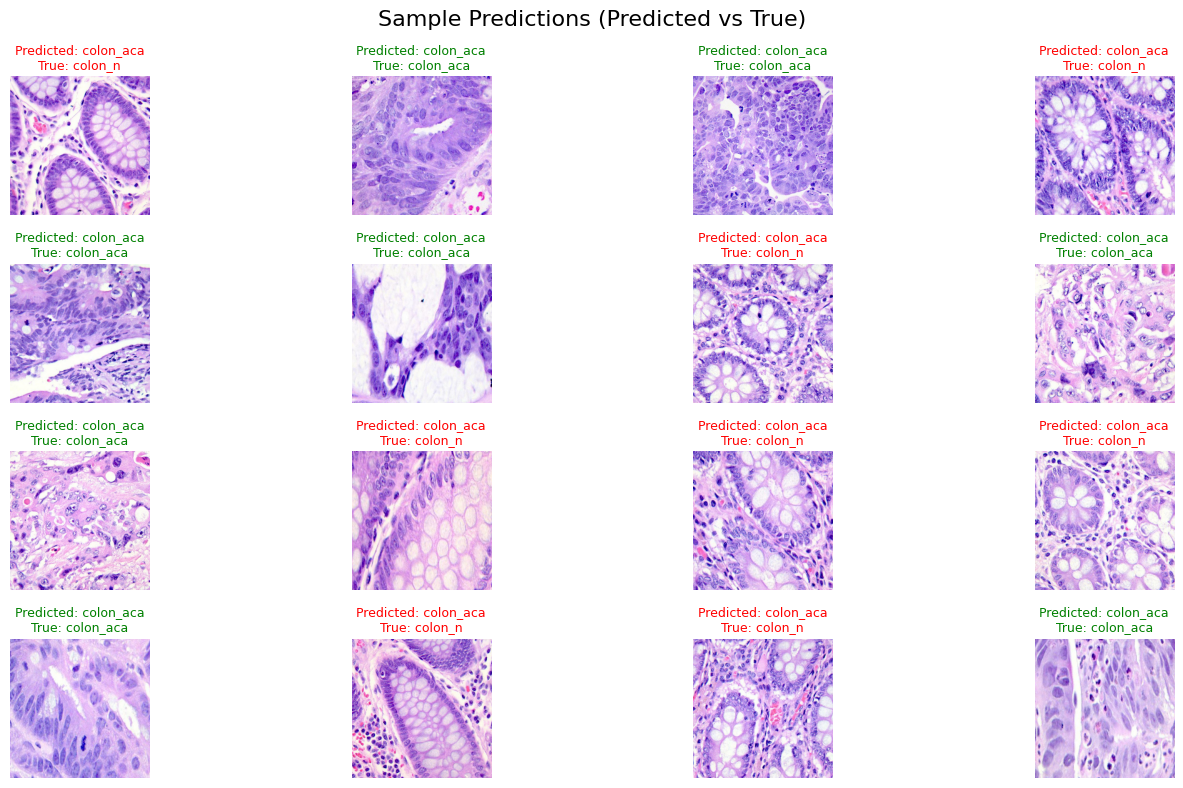

In [19]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Take a batch of 16 RAW test images for clear visualization
# We use test_ds_raw which was defined earlier
images_raw, labels = next(iter(test_ds_raw.unbatch().batch(16)))

# Preprocess the images ONLY for getting predictions
# We cast to float32 then apply MobileNetV2's specific scaling
images_preprocessed = preprocess_input(tf.cast(images_raw, tf.float32))

# Get predictions
pred_probs = mobilenet_model.predict(images_preprocessed, verbose=0)
pred_classes = np.argmax(pred_probs, axis=1)

# Plot images with predicted vs true labels
plt.figure(figsize=(15, 8))
for i in range(16):
    plt.subplot(4, 4, i + 1)

    # Display the raw image so it doesn't look noisy or distorted
    plt.imshow(images_raw[i].numpy().astype("uint8"))
    plt.axis("off")

    true_label = labels[i].numpy()
    pred_label = pred_classes[i]

    # Convert class index -> class name
    true_name = class_names[true_label]
    pred_name = class_names[pred_label]

    # Show result (Green if correct, Red if wrong)
    color = "green" if pred_label == true_label else "red"
    # CHANGED: 'P' -> 'Predicted' and 'T' -> 'True'
    plt.title(f"Predicted: {pred_name}\nTrue: {true_name}", color=color, fontsize=9)

plt.suptitle("Sample Predictions (Predicted vs True)", fontsize=16)
plt.tight_layout()
plt.show()

In [18]:
# Save the model in the native Keras format
mobilenet_model.save('best_colon_cancer_model.keras')

print("Model saved successfully as 'best_colon_cancer_model.keras'")

Model saved successfully as 'best_colon_cancer_model.keras'
